# Tutorial 8 · Learned nowcasting: training a small neural network

Tutorial 07 built nowcasts from physics-inspired rules: estimate the motion, move the
field, let small scales decay. A neural network can instead **learn** the mapping from
the last few radar fields to the next ones from examples. This notebook trains a compact
convolutional network (a U-Net, the architecture of RainNet; Ayzel et al., 2020) on the
OpenRainER radar, on a CPU in a few minutes, and compares it fairly with persistence,
extrapolation and S-PROG.

| | |
|---|---|
| **Data** | OpenRainER radar, Emilia-Romagna, 14–21 August 2022, 15-min rain rates, averaged to 4 km |
| **You will learn** | building a nowcasting dataset without leakage; the transform and the loss; a U-Net in PyTorch; a training loop with validation and early stopping; a like-for-like comparison with pysteps; why networks trained on squared error blur, and what is done about it |
| **Runtime** | about 6 minutes on a laptop CPU, almost all of it training |
| **Prerequisites** | [07 · Nowcasting with pysteps](07_nowcasting_with_pysteps.ipynb) for the baselines and scores; basic PyTorch |

**Contents**
1. The learning problem
2. Data and a leakage-free split
3. Transform, samples and augmentation
4. The model
5. Training
6. Forecasting the test storm
7. Comparison with persistence, extrapolation and S-PROG
8. Why the network blurs, and what is done about it
9. Where FieldSense takes this further
10. References and links

## 0. Setup

`OMP_NUM_THREADS` is set before NumPy, PyTorch and pysteps are imported: on some macOS
builds, PyTorch and pysteps' OpenMP-parallel routines crash when both start their own
thread pools in one process. Seeds are fixed so the run is reproducible.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")   # PyTorch + pysteps OpenMP in one process can crash on macOS

import contextlib, io, sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import ndimage

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from core.opensense import example_data
from pysteps import motion, nowcasts, verification
from pysteps.extrapolation.semilagrangian import extrapolate
from pysteps.utils import transformation


@contextlib.contextmanager
def quiet():
    with contextlib.redirect_stdout(io.StringIO()):
        yield


SEED = 0
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 10})
T0 = time.time()

## 1. The learning problem

Given the last $p$ fields $R_{t-p+1}, \dots, R_t$, predict the next $q$:

$$f_\theta:\; (R_{t-p+1}, \dots, R_t) \;\mapsto\; (\hat R_{t+1}, \dots, \hat R_{t+q}).$$

We take $p = 4$ (one hour of history, as the Lucas–Kanade motion in tutorial 07) and
$q = 4$ (15 to 60 minutes ahead), and predict all four leads at once rather than feeding
predictions back in, which avoids compounding errors during training. The parameters
$\theta$ are fitted by minimising the mean squared error between predicted and observed
(transformed) fields over many past examples.

Two things make this harder than it looks: **few independent examples** (eight days of
radar contain only a handful of storms), and **autocorrelation** (neighbouring time steps
are nearly identical, so a careless split leaks the test set into training).

## 2. Data and a leakage-free split

The OpenRainER radar (Covi & Roversi, [doi:10.5281/zenodo.10593848](https://doi.org/10.5281/zenodo.10593848))
from the OpenSense example subset: eight days at 15 minutes, already in mm/h. Averaging
to 4 km pixels keeps CPU training to minutes; the method is the same at any resolution.

The split is by **contiguous time blocks**, with gaps of at least three hours between
them, so no input or target frame is shared and the strongest short-range correlation is
broken:

| set | period (UTC) | use |
|---|---|---|
| train | 14 Aug 00:00 – 17 Aug 23:45, and 20 Aug 03:00 – 21 Aug 23:45 | fit the weights |
| validation | 19 Aug 03:00 – 23:45 | choose when to stop |
| test | 18 Aug 03:00 – 14:00 | the storm of tutorial 07, scored once at the end |

A random split of individual samples would put frames from the same hour of the same
storm into train and test, and report skill the model does not have.

  [skip]  openrainer_cml_8d.nc  (0.83 MB, already present)


  [skip]  openrainer_radar_8d.nc  (15.98 MB, already present)


  [skip]  openrainer_gauges_8d.nc  (0.13 MB, already present)


{'units': 'mm h-1', 'comment': 'converted from 0.25 h accumulation in mm'}


768 fields, grid (72, 93) at 4.0 km


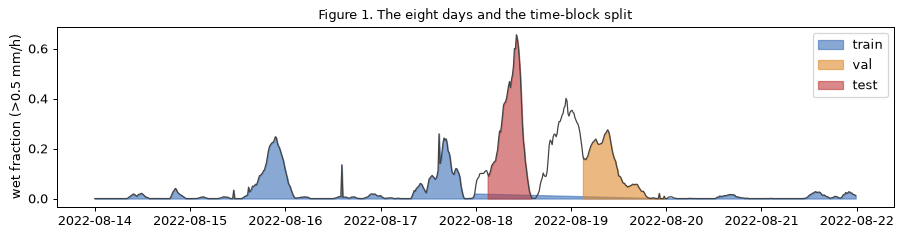

In [2]:
radar = example_data.load("openrainer", "8d", components=("radar",))["radar"]["R"]
print({k: radar.attrs[k] for k in ("units", "comment")})
field = radar.coarsen(x=4, y=4, boundary="trim").mean()               # 1 km -> 4 km
R = np.nan_to_num(field.values).astype(np.float32)                      # (time, y, x) mm/h
times = pd.DatetimeIndex(field.time.values)
KM = float(np.diff(field.x.values).mean()) / 1000
STEP_MIN, P, Q = 15, 4, 4
print(f"{R.shape[0]} fields, grid {R.shape[1:]} at {KM:.1f} km")


def block(a, b):
    return np.where((times >= pd.Timestamp(a)) & (times <= pd.Timestamp(b)))[0]


blocks = {
    "train": np.r_[block("2022-08-14T00:00", "2022-08-17T23:45"), block("2022-08-20T03:00", "2022-08-21T23:45")],
    "val": block("2022-08-19T03:00", "2022-08-19T23:45"),
    "test": block("2022-08-18T03:00", "2022-08-18T14:00"),
}

wet = (R > 0.5).mean(axis=(1, 2))
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.plot(times, wet, color="#444", lw=1)
for name, color in zip(blocks, ("#3b6fb6", "#e08a2e", "#c03b3b")):
    ax.fill_between(times[blocks[name]], 0, wet[blocks[name]], color=color, alpha=0.6, label=name)
ax.set(ylabel="wet fraction (>0.5 mm/h)", title="Figure 1. The eight days and the time-block split")
ax.legend(); plt.show()

## 3. Transform, samples and augmentation

**Transform.** Rain rates are skewed: a squared-error loss on raw mm/h is dominated by a
few intense pixels. We train on

$$x = \tfrac{1}{2}\log(1 + R),$$

which compresses the range like the dB transform of tutorial 07 but is defined at zero,
and invert it with $R = \exp(2x) - 1$.

**Samples.** A sample is a window of $p + q = 8$ consecutive frames that lies entirely
inside one block. For training we keep windows whose last input frame has at least 3% of
pixels above 0.5 mm/h: dry windows teach only that nothing happens.

**Augmentation.** Each training sample is a random 32×32-pixel crop (128 km), rotated by a
multiple of 90° and mirrored at random. Rain physics does not depend on the compass
direction, so these eight symmetries multiply the variety of motion directions the network
sees: the training storms all move roughly the same way.

In [3]:
X = np.log1p(R) / 2.0
to_rate = lambda x: np.expm1(2.0 * np.clip(x, 0, None))


def windows(idx, min_wet=0.0):
    inside = set(idx.tolist())
    keep = [i for i in idx if all((i + k) in inside for k in range(-P + 1, Q + 1)) and wet[i] >= min_wet]
    return np.array(keep)


win = {"train": windows(blocks["train"], 0.03), "val": windows(blocks["val"], 0.01),
       "test": windows(blocks["test"])}
print({k: len(v) for k, v in win.items()}, "windows (train/val: wet ones only)")

CROP = 32


def train_batch(n=16):
    xs, ys = [], []
    for _ in range(n):
        i = rng.choice(win["train"])
        y0, x0 = rng.integers(0, X.shape[1] - CROP), rng.integers(0, X.shape[2] - CROP)
        s = X[i - P + 1:i + Q + 1, y0:y0 + CROP, x0:x0 + CROP]
        s = np.rot90(s, rng.integers(4), axes=(1, 2))
        if rng.random() < 0.5:
            s = s[:, :, ::-1]
        xs.append(s[:P].copy()); ys.append(s[P:].copy())
    return torch.from_numpy(np.stack(xs)), torch.from_numpy(np.stack(ys))

{'train': 94, 'val': 62, 'test': 38} windows (train/val: wet ones only)


## 4. The model

A **U-Net** (Ronneberger et al., 2015) encodes the input at three resolutions, 4, 8 and
16 km here, and decodes back to full resolution, concatenating encoder features at each
level (*skip connections*) so fine detail is not lost in the bottleneck. The four input
frames enter as channels, so motion is seen as differences between channels; the output
has four channels, one per lead time, passed through a ReLU because rain is non-negative.
RainNet (Ayzel et al., 2020) is the same idea at full size; this one has about 117,000
parameters.

Recurrent alternatives (ConvLSTM, Shi et al., 2015; ConvGRU, Ballas et al., 2016) carry a
hidden state through time instead of stacking frames as channels; they suit longer and
variable-length sequences, at a higher training cost.

In [4]:
class DoubleConv(nn.Sequential):
    def __init__(self, c_in, c_out):
        super().__init__(nn.Conv2d(c_in, c_out, 3, padding=1), nn.ReLU(),
                         nn.Conv2d(c_out, c_out, 3, padding=1), nn.ReLU())


class UNet(nn.Module):
    def __init__(self, c=(16, 32, 64), n_in=P, n_out=Q):
        super().__init__()
        self.enc1, self.enc2, self.bottom = DoubleConv(n_in, c[0]), DoubleConv(c[0], c[1]), DoubleConv(c[1], c[2])
        self.up2, self.dec2 = nn.ConvTranspose2d(c[2], c[1], 2, stride=2), DoubleConv(2 * c[1], c[1])
        self.up1, self.dec1 = nn.ConvTranspose2d(c[1], c[0], 2, stride=2), DoubleConv(2 * c[0], c[0])
        self.head = nn.Conv2d(c[0], n_out, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        b = self.bottom(F.max_pool2d(e2, 2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return F.relu(self.head(d1))


def predict(model, x_in):
    # x_in: (n, P, ny, nx) transformed; pads to a multiple of 4 so both poolings fit
    ny, nx = x_in.shape[-2:]
    py, px = (-ny) % 4, (-nx) % 4
    with torch.no_grad():
        out = model(F.pad(torch.as_tensor(x_in), (0, px, 0, py), mode="replicate"))
    return out[..., :ny, :nx].numpy()


model = UNet()
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

117,236 parameters


## 5. Training

Adam with learning rate $10^{-3}$, batches of 16 crops, mean squared error in the
transformed space. Every 100 iterations the loss is computed on all validation windows
(full domain); the weights with the lowest validation loss are kept (**early stopping**),
which guards against fitting the few training storms too closely.

trained 1200 iterations in 2.9 min; best validation loss 0.0365 at iteration 1000


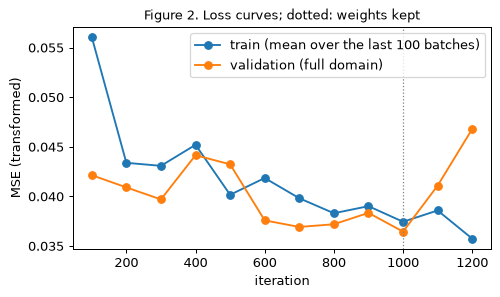

In [5]:
N_ITER, EVAL_EVERY = 1200, 100
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
xv = np.stack([X[i - P + 1:i + 1] for i in win["val"]])
yv = np.stack([X[i + 1:i + Q + 1] for i in win["val"]])

history, best = [], (np.inf, None, 0)
running = []
t = time.time()
for it in range(1, N_ITER + 1):
    model.train()
    xb, yb = train_batch()
    loss = F.mse_loss(model(xb), yb)
    opt.zero_grad(); loss.backward(); opt.step()
    running.append(loss.item())
    if it % EVAL_EVERY == 0:
        model.eval()
        val = float(np.mean((predict(model, xv) - yv) ** 2))
        history.append({"iteration": it, "train": np.mean(running), "val": val})
        running = []
        if val < best[0]:
            best = (val, {k: v.clone() for k, v in model.state_dict().items()}, it)
model.load_state_dict(best[1]); model.eval()
print(f"trained {N_ITER} iterations in {(time.time() - t) / 60:.1f} min; best validation loss "
      f"{best[0]:.4f} at iteration {best[2]}")

hist = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(hist.iteration, hist.train, marker="o", label="train (mean over the last 100 batches)")
ax.plot(hist.iteration, hist.val, marker="o", label="validation (full domain)")
ax.axvline(best[2], color="grey", ls=":", lw=1)
ax.set(xlabel="iteration", ylabel="MSE (transformed)", title="Figure 2. Loss curves; dotted: weights kept")
ax.legend(); plt.show()

## 6. Forecasting the test storm

The test storm is 18 August 2022, the case of tutorial 07, never seen in training or
validation. Issue times every 30 minutes from 05:00 to 11:30 UTC. The baselines are
computed on the same 4 km fields:

- **persistence**: the last field, unchanged;
- **extrapolation**: Lucas–Kanade motion on dBR, semi-Lagrangian advection;
- **S-PROG**: the cascade method of tutorial 07 (5 levels on this grid).

All methods are scored on the cells reachable from inside the domain by the extrapolation
(tutorial 07, section 7), so no method is charged for rain that enters from outside.

14 issue times, 4 methods


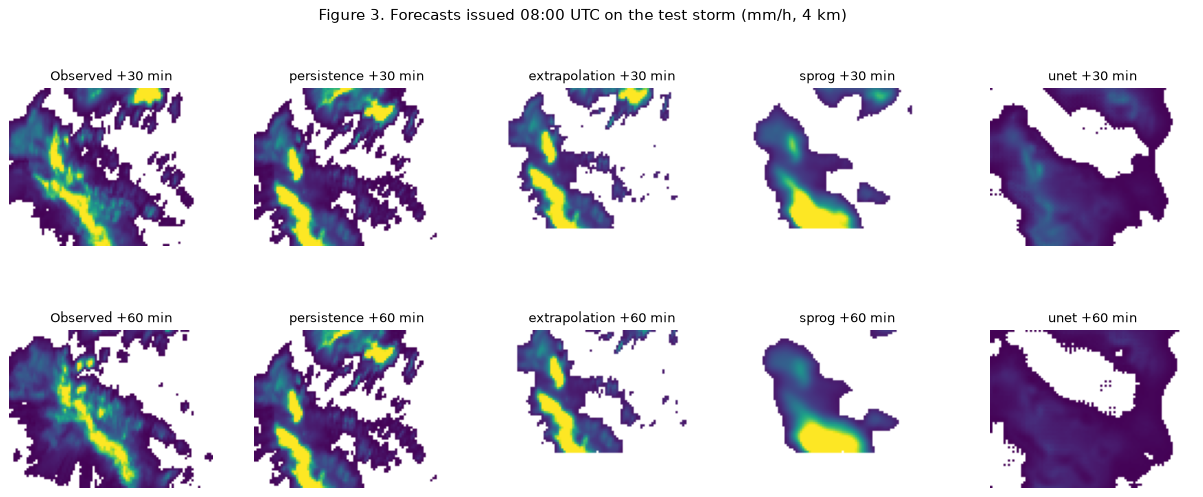

In [6]:
meta = {"transform": None, "threshold": 0.1, "zerovalue": 0.0, "unit": "mm/h", "accutime": float(STEP_MIN),
        "xpixelsize": KM * 1000, "ypixelsize": KM * 1000, "yorigin": "lower"}
issues = [i for i in win["test"] if times[i].minute in (0, 30)
          and pd.Timestamp("2022-08-18T05:00") <= times[i] <= pd.Timestamp("2022-08-18T11:30")]


def baselines(i):
    d = transformation.dB_transform(R[i - 3:i + 1], meta, threshold=0.1, zerovalue=-15.0)[0]
    with quiet():
        V = motion.get_method("LK")(d, verbose=False)
        ext = nowcasts.get_method("extrapolation")(d[-1], V, Q, extrap_kwargs={"allow_nonfinite_values": True})
        spr = nowcasts.get_method("sprog")(d[-3:], V, Q, n_cascade_levels=5, precip_thr=0.1)
        valid = np.isfinite(extrapolate(np.ones(R.shape[1:]), V, Q, allow_nonfinite_values=True))
    inv = lambda f: transformation.dB_transform(f, threshold=0.1, inverse=True)[0]
    return {"persistence": np.repeat(R[i:i + 1], Q, axis=0), "extrapolation": inv(ext), "sprog": inv(spr)}, valid


unet_all = to_rate(predict(model, np.stack([X[i - P + 1:i + 1] for i in issues])))
forecasts, masks = [], []
for n, i in enumerate(issues):
    f, valid = baselines(i)
    f["unet"] = unet_all[n]
    forecasts.append(f); masks.append(valid)
METHODS = ["persistence", "extrapolation", "sprog", "unet"]
print(f"{len(issues)} issue times, {len(METHODS)} methods")

k_show = issues.index(times.get_loc(pd.Timestamp("2022-08-18T08:00")))
i_show = issues[k_show]
fig, axes = plt.subplots(2, 5, figsize=(17, 6.4))
for r, lead in enumerate((1, 3)):
    panels = [("Observed", R[i_show + lead + 1])] + [(m, forecasts[k_show][m][lead]) for m in METHODS]
    for ax, (title, f) in zip(axes[r], panels):
        ax.imshow(np.ma.masked_less(np.nan_to_num(f), 0.1), origin="lower", cmap="viridis", vmin=0, vmax=20)
        ax.set_title(f"{title} +{(lead + 1) * STEP_MIN} min"); ax.axis("off")
fig.suptitle(f"Figure 3. Forecasts issued {times[i_show]:%H:%M} UTC on the test storm (mm/h, 4 km)")
plt.show()

## 7. Comparison with persistence, extrapolation and S-PROG

The same scores as tutorial 07, pooled over the issue times: CSI at 1 mm/h, MAE, and the
fractions skill score at 60 minutes. To see blurring directly we also track the
**spatial standard deviation** of each forecast relative to the observed field
(1 means as much variability as reality; below 1 means smoother) and the share of
verifiable pixels above 5 mm/h.

In [7]:
def masked_fss(f, o, valid, thr, scale):
    w = valid.astype(float)
    cover = ndimage.uniform_filter(w, scale, mode="constant")
    inside = valid & (cover > 0.5)
    pf = ndimage.uniform_filter((np.nan_to_num(f) >= thr) * w, scale, mode="constant") / np.maximum(cover, 1e-9)
    po = ndimage.uniform_filter((o >= thr) * w, scale, mode="constant") / np.maximum(cover, 1e-9)
    return np.sum((pf - po)[inside] ** 2), np.sum(pf[inside] ** 2 + po[inside] ** 2)


THR, SCALES = 1.0, (1, 3, 5, 10)
rows, fss_rows = [], []
for m in METHODS:
    for lead in range(Q):
        cat = verification.det_cat_fct_init(THR)
        err, sd_f, sd_o, heavy_f, heavy_o = [], [], [], [], []
        for n, i in enumerate(issues):
            valid = masks[n][lead]
            f, o = np.nan_to_num(forecasts[n][m][lead])[valid], R[i + lead + 1][valid]
            verification.det_cat_fct_accum(cat, f, o)
            err.append(np.abs(f - o)); sd_f.append(f.std()); sd_o.append(o.std())
            heavy_f.append((f > 5).mean()); heavy_o.append((o > 5).mean())
        rows.append({"method": m, "lead_min": (lead + 1) * STEP_MIN,
                     "CSI": float(verification.det_cat_fct_compute(cat, scores="CSI")["CSI"]),
                     "MAE": float(np.concatenate(err).mean()),
                     "std ratio": float(np.mean(sd_f) / np.mean(sd_o)),
                     "> 5 mm/h, forecast": float(np.mean(heavy_f)), "> 5 mm/h, observed": float(np.mean(heavy_o))})
    for s in SCALES:
        num = den = 0.0
        for n, i in enumerate(issues):
            a, b = masked_fss(forecasts[n][m][3], R[i + 4], masks[n][3], THR, s)
            num, den = num + a, den + b
        fss_rows.append({"method": m, "window_km": s * KM, "FSS": 1 - num / den})
scores = pd.DataFrame(rows)
fss = pd.DataFrame(fss_rows)
scores.pivot(index="method", columns="lead_min", values=["CSI", "MAE", "std ratio"]).round(2)

CSI                     MAE                   std ratio        \
lead_min         15    30    45    60    15    30    45    60        15    30   
method                                                                          
extrapolation  0.81  0.71  0.64  0.58  1.26  1.99  2.46  2.80      0.99  0.97   
persistence    0.68  0.54  0.45  0.37  2.19  3.24  3.86  4.33      1.02  1.02   
sprog          0.81  0.72  0.67  0.61  1.25  1.94  2.35  2.65      1.00  1.01   
unet           0.73  0.64  0.55  0.45  1.57  2.18  2.54  2.79      0.61  0.32   

                           
lead_min         45    60  
method                     
extrapolation  0.98  0.97  
persistence    1.06  1.08  
sprog          1.04  1.03  
unet           0.22  0.15

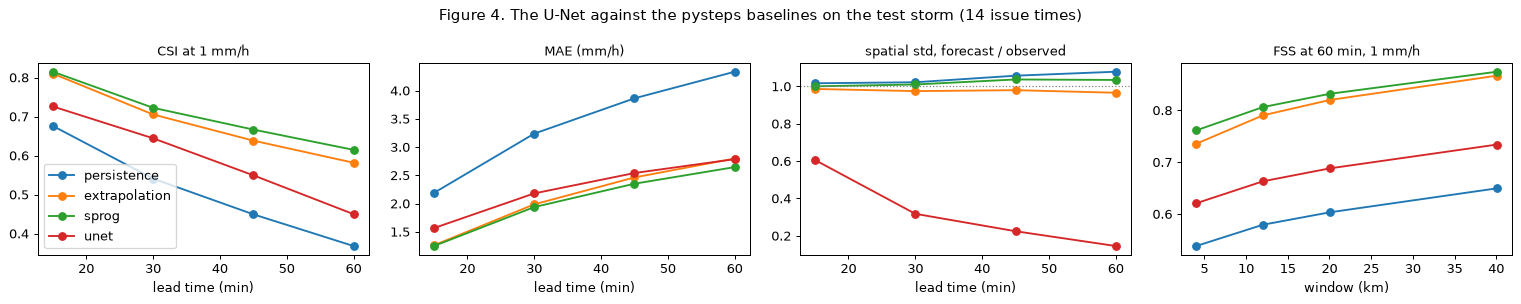

,"> 5 mm/h, forecast","> 5 mm/h, observed"
method,,
persistence,0.226,0.216
extrapolation,0.180,0.216
sprog,0.189,0.216
unet,0.000,0.216


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.4))
for m in METHODS:
    d = scores[scores.method == m]
    for ax, col in zip(axes[:3], ("CSI", "MAE", "std ratio")):
        ax.plot(d.lead_min, d[col], marker="o", label=m)
    d = fss[fss.method == m]
    axes[3].plot(d.window_km, d.FSS, marker="o", label=m)
axes[0].set(title=f"CSI at {THR:g} mm/h", xlabel="lead time (min)")
axes[1].set(title="MAE (mm/h)", xlabel="lead time (min)")
axes[2].set(title="spatial std, forecast / observed", xlabel="lead time (min)"); axes[2].axhline(1, color="grey", lw=1, ls=":")
axes[3].set(title=f"FSS at 60 min, {THR:g} mm/h", xlabel="window (km)")
axes[0].legend()
fig.suptitle(f"Figure 4. The U-Net against the pysteps baselines on the test storm ({len(issues)} issue times)")
plt.tight_layout(); plt.show()
scores[scores.lead_min == 60].set_index("method")[["> 5 mm/h, forecast", "> 5 mm/h, observed"]].round(3)

**What the numbers say** (from the executed run; they shift slightly with the seed).
The network has learnt something real: it beats persistence at every lead (at 60 min,
CSI 0.45 against 0.37 and MAE 2.79 against 4.33 mm/h), and its 60-minute MAE equals that
of extrapolation (2.79 against 2.80 mm/h). But it falls well short of extrapolation and
S-PROG in CSI (0.45 against 0.58 and 0.61) and in FSS at every window, and its fields
lose their variability quickly: at 60 min their spatial standard deviation is 15% of the
observed one, and not one verifiable pixel exceeds 5 mm/h, against 22% observed.
Figure 3 shows why: the network smears rain over the area where it *might* be. The
validation loss also turns up after about 1000 iterations as the few training storms
start to be memorised; early stopping keeps the weights at its minimum. With eight days
of data this is the expected outcome, and the reason for the larger datasets,
structure-aware losses and generative models of section 8.

## 8. Why the network blurs, and what is done about it

A network trained to minimise squared error predicts the **conditional mean** of the
future given the past: $\hat R = \mathbb{E}[R_{t+\tau} \mid R_{t-p+1..t}]$. When the future
is uncertain, as the exact position of a convective cell an hour ahead is, the mean
spreads its rain over every plausible position. The forecast becomes smooth, the light
rain area grows and peaks shrink: a good score for MAE, a poor picture of a storm.
S-PROG also discards the scales it cannot predict, but then remaps its field to the
observed intensity distribution (pysteps' default CDF probability matching), so it keeps
realistic intensities; extrapolation moves the observed field and keeps them by
construction. That is why both keep a standard deviation ratio near 1 in Figure 4.

Remedies used in research and practice:

- **Losses that reward structure**: weighted or threshold-based losses, or a loss on
  pooled fields, so intense rain is not traded for a smooth mean.
- **Generative models** that sample futures rather than average them: DGMR (Ravuri et
  al., 2021) uses a conditional GAN and was preferred by forecasters in blind tests;
  diffusion models follow the same logic.
- **Ensembles**: as STEPS does with noise, several samples express the uncertainty that a
  single smooth field hides.
- **More data**: eight days and a handful of storms are a toy; operational networks are
  trained on years of radar.

And two cautions for any comparison: verify on **storms held out in time** (section 2),
and score all methods on the **same cells and issue times**.

## 9. Where FieldSense takes this further

[`projects/spatial_interpolation`](../projects/spatial_interpolation/README.md) asks the
same question for rain maps made from **commercial microwave links** instead of radar.
Its first stage turns link attenuation into rain rates with a recurrent network and
interpolates them onto a grid; its second stage forecasts those maps 15–60 minutes ahead
with a Transformer, POD-SINDy (a sparse dynamical model on the leading spatial modes) and
a Mamba-style state-space model, against persistence and a pysteps baseline. A key idea
there is **CML self-supervision**: training on future link-derived maps alone, with no
radar or gauge reference, so the method needs nothing beyond the links. Its results are
scored point-to-pixel against gauges and grid-to-grid against radar; tutorial 07 shows why
the motion in link maps is a particular difficulty.

In [9]:
print(f"Notebook run time: {(time.time() - T0) / 60:.1f} min")

Notebook run time: 3.1 min


## 10. References and links

**Software and data**
- PyTorch: <https://pytorch.org/docs/stable/index.html>
- pysteps: <https://pysteps.readthedocs.io/en/stable/>
- Covi, E. and Roversi, G.: OpenRainER. <https://doi.org/10.5281/zenodo.10593848>
- OpenSense example data: <https://github.com/OpenSenseAction/opensense_example_data>
- FieldSense: [07 · Nowcasting with pysteps](07_nowcasting_with_pysteps.ipynb), [`projects/nowcasting/pysteps`](../projects/nowcasting/pysteps/README.md), [`projects/spatial_interpolation`](../projects/spatial_interpolation/README.md)

**Methods**
- Ronneberger, O., Fischer, P. and Brox, T. (2015): U-Net: convolutional networks for biomedical image segmentation. <https://arxiv.org/abs/1505.04597>
- Ayzel, G., Scheffer, T. and Heistermann, M. (2020): RainNet v1.0: a convolutional neural network for radar-based precipitation nowcasting. *Geosci. Model Dev.*, 13, 2631–2644. <https://doi.org/10.5194/gmd-13-2631-2020>
- Shi, X. et al. (2015): Convolutional LSTM network: a machine learning approach for precipitation nowcasting. <https://arxiv.org/abs/1506.04214>
- Ballas, N. et al. (2016): Delving deeper into convolutional networks for learning video representations (ConvGRU). <https://arxiv.org/abs/1511.06432>
- Ravuri, S. et al. (2021): Skilful precipitation nowcasting using deep generative models of radar. *Nature*, 597, 672–677. <https://doi.org/10.1038/s41586-021-03854-z>
- Pulkkinen, S. et al. (2019): Pysteps: an open-source Python library for probabilistic precipitation nowcasting (v1.0). *Geosci. Model Dev.*, 12, 4185–4219. <https://doi.org/10.5194/gmd-12-4185-2019>
- Roberts, N. M. and Lean, H. W. (2008): Scale-selective verification of rainfall accumulations (FSS). *Mon. Wea. Rev.*, 136, 78–97. <https://doi.org/10.1175/2007MWR2123.1>